# Определение стоимости автомобилей

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение для привлечения новых клиентов. В нём можно быстро узнать рыночную стоимость своего автомобиля. В вашем распоряжении исторические данные: технические характеристики, комплектации и цены автомобилей. Вам нужно построить модель для определения стоимости. 

Заказчику важны:

- качество предсказания;
- скорость предсказания;
- время обучения.

In [1]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgbm
from lightgbm import LGBMRegressor
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_squared_error

In [2]:
def load_dataset(name, **kwargs):
    """Читает датасет из локальной папки datasets/, при её отсутствии — с code.s3.yandex.net."""
    local = os.path.join('datasets', name)
    source = local if os.path.exists(local) else 'https://code.s3.yandex.net/datasets/' + name
    return pd.read_csv(source, **kwargs)

df = load_dataset('autos.csv')
# в актуальной версии датасета столбец называется Repaired (ранее NotRepaired)
df = df.rename(columns={'Repaired': 'NotRepaired'})
df.head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


## Подготовка данных

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   DateCrawled        354369 non-null  str  
 1   Price              354369 non-null  int64
 2   VehicleType        316879 non-null  str  
 3   RegistrationYear   354369 non-null  int64
 4   Gearbox            334536 non-null  str  
 5   Power              354369 non-null  int64
 6   Model              334664 non-null  str  
 7   Kilometer          354369 non-null  int64
 8   RegistrationMonth  354369 non-null  int64
 9   FuelType           321474 non-null  str  
 10  Brand              354369 non-null  str  
 11  NotRepaired        283215 non-null  str  
 12  DateCreated        354369 non-null  str  
 13  NumberOfPictures   354369 non-null  int64
 14  PostalCode         354369 non-null  int64
 15  LastSeen           354369 non-null  str  
dtypes: int64(7), str(9)
memory usage: 43.3 MB


In [4]:
df['PostalCode'] = df['PostalCode']//1000

In [5]:
df['LastSeen_Year'] = pd.to_datetime(df['LastSeen']).dt.year
# возраст объявления в днях: от создания анкеты до последней активности
df['Age'] = (pd.to_datetime(df['LastSeen']) - pd.to_datetime(df['DateCreated'])).dt.days
df['Age']

0         14
1         14
2         22
3          0
4          6
          ..
354364     0
354365    23
354366     6
354367    19
354368     4
Name: Age, Length: 354369, dtype: int64

In [6]:
df.describe(include='all')

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen,LastSeen_Year,Age
count,354369,354369.000000,316879,354369.000000,334536,354369.000000,334664,354369.000000,354369.000000,321474,354369,283215,354369,354369.0,354369.000000,354369,354369.0,354369.000000
unique,271174,NaN,8,NaN,2,NaN,250,NaN,NaN,7,40,2,109,NaN,NaN,179150,NaN,NaN
top,2016-03-24 14:49:47,NaN,sedan,NaN,manual,NaN,golf,NaN,NaN,petrol,volkswagen,no,2016-04-03 00:00:00,NaN,NaN,2016-04-06 13:45:54,NaN,NaN
freq,7,NaN,91457,NaN,268251,NaN,29232,NaN,NaN,216352,77013,247161,13719,NaN,NaN,17,NaN,NaN
mean,NaN,4416.656776,NaN,2004.234448,NaN,110.094337,NaN,128211.172535,5.714645,NaN,NaN,NaN,NaN,0.0,50.061964,NaN,2016.0,8.677974
std,NaN,4514.158514,NaN,90.227958,NaN,189.850405,NaN,37905.341530,3.726421,NaN,NaN,NaN,NaN,0.0,25.795614,NaN,0.0,8.639404
min,NaN,0.000000,NaN,1000.000000,NaN,0.000000,NaN,5000.000000,0.000000,NaN,NaN,NaN,NaN,0.0,1.000000,NaN,2016.0,0.000000
25%,NaN,1050.000000,NaN,1999.000000,NaN,69.000000,NaN,125000.000000,3.000000,NaN,NaN,NaN,NaN,0.0,30.000000,NaN,2016.0,2.000000
50%,NaN,2700.000000,NaN,2003.000000,NaN,105.000000,NaN,150000.000000,6.000000,NaN,NaN,NaN,NaN,0.0,49.000000,NaN,2016.0,6.000000
75%,NaN,6400.000000,NaN,2008.000000,NaN,143.000000,NaN,150000.000000,9.000000,NaN,NaN,NaN,NaN,0.0,71.000000,NaN,2016.0,13.000000


Заполнение пропусков, отсечение выбросов и кодирование категорий выполняем **после** разбиения на выборки: все статистики (мода, квантили, кодировщики) считаются только по обучающей выборке, чтобы избежать утечки данных в тест.

In [7]:
df = df.drop(['DateCrawled', 'DateCreated', 'LastSeen', 'NumberOfPictures'], axis=1)
df_train, df_test = train_test_split(df, test_size=0.25, random_state=12345)
df_train.shape, df_test.shape

((265776, 14), (88593, 14))

In [8]:
# пропуски в категориальных признаках заполняем модой, рассчитанной по обучающей выборке
fill_values = df_train.mode().iloc[0]
df_train = df_train.fillna(fill_values)
df_test = df_test.fillna(fill_values)
df_train.isna().sum().sum(), df_test.isna().sum().sum()

(np.int64(0), np.int64(0))

In [9]:
# отсечение выбросов по 1% и 99% квантилям, рассчитанным на обучающей выборке
numeric = ['RegistrationYear', 'Power', 'Price']
bounds = df_train[numeric].quantile([0.01, 0.99])


def remove_outliers(frame):
    mask = pd.Series(True, index=frame.index)
    for col in numeric:
        mask &= frame[col].between(bounds.loc[0.01, col], bounds.loc[0.99, col], inclusive='neither')
    return frame[mask]


df_train = remove_outliers(df_train)
df_test = remove_outliers(df_test)
df_train.shape, df_test.shape

((221528, 14), (73785, 14))

Добавим категориальный признак «возрастная группа автомобиля» по году регистрации:

In [10]:
def age(row):
    year = row['RegistrationYear']
    if year < 1991:
        return 'super_retro'
    elif year < 2001:
        return 'retro'
    elif year < 2011:
        return 'super_old'
    elif year < 2015:
        return 'old'
    return 'new'


df_train['car_age'] = df_train.apply(age, axis=1)
df_test['car_age'] = df_test.apply(age, axis=1)

Подготовим два варианта датасета: One Hot Encoding и Ordinal Encoding (кодировщик обучаем только на train):

In [11]:
X_train = pd.get_dummies(df_train.drop('Price', axis=1), drop_first=True)
X_test = pd.get_dummies(df_test.drop('Price', axis=1), drop_first=True)
# выравниваем состав колонок теста по train (категории, не встретившиеся в train, отбрасываются)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
y_train = df_train['Price']
y_test = df_test['Price']
X_train.shape, X_test.shape

((221528, 312), (73785, 312))

In [12]:
cat_cols = ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'NotRepaired', 'PostalCode', 'car_age']
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_enc = df_train.drop('Price', axis=1).copy()
X_test_enc = df_test.drop('Price', axis=1).copy()
X_train_enc[cat_cols] = enc.fit_transform(X_train_enc[cat_cols])
X_test_enc[cat_cols] = enc.transform(X_test_enc[cat_cols])
y_train_enc, y_test_enc = y_train, y_test
X_train_enc.shape, X_test_enc.shape

((221528, 14), (73785, 14))

## Обучение моделей

In [13]:
def score_ohe(model):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return (mean_squared_error(y_test, pred)**0.5)

In [14]:
def score_enc(model):
    model.fit(X_train_enc, y_train_enc)
    pred = model.predict(X_test_enc)
    return (mean_squared_error(y_test_enc, pred)**0.5)

In [15]:
%%time
model = DecisionTreeRegressor(random_state=12345)
score_ohe(model)

CPU times: user 3.87 s, sys: 164 ms, total: 4.04 s
Wall time: 4.04 s


1903.536886070084

In [16]:
%%time
model = DecisionTreeRegressor(random_state=12345)
score_enc(model)

CPU times: user 1.03 s, sys: 16.2 ms, total: 1.05 s
Wall time: 1.05 s


1982.3949545128103

In [17]:
%%time
model = LinearRegression()
score_ohe(model)

CPU times: user 5.2 s, sys: 715 ms, total: 5.92 s
Wall time: 2.59 s


2140.9098903269864

In [18]:
%%time
model = LinearRegression()
score_enc(model)

CPU times: user 385 ms, sys: 11.7 ms, total: 396 ms
Wall time: 98.2 ms


2657.071238715028

In [19]:
%%time
model = RandomForestRegressor(random_state=12345, n_estimators=10, n_jobs=4)
score_ohe(model)

CPU times: user 22.3 s, sys: 201 ms, total: 22.5 s
Wall time: 6.91 s


1483.2767844801635

In [20]:
%%time
model = RandomForestRegressor(random_state=12345, n_estimators=10, n_jobs=4)
score_enc(model)

CPU times: user 6.84 s, sys: 67.9 ms, total: 6.91 s
Wall time: 2.08 s


1496.3032222596462

In [21]:
%%time
model = RandomForestRegressor(random_state=12345, n_estimators=100, n_jobs=4)
score_enc(model)

CPU times: user 1min 7s, sys: 999 ms, total: 1min 8s
Wall time: 17.4 s


1429.686456886025

## XGBoost

In [22]:
def score_(model, X_train, X_test, y_train, y_test, stopping_rounds):
    # для ранней остановки выделяем хвост обучающей выборки, чтобы не подсматривать в тест
    val_size = len(X_train) // 10
    X_tr, X_val = X_train.iloc[:-val_size], X_train.iloc[-val_size:]
    y_tr, y_val = y_train.iloc[:-val_size], y_train.iloc[-val_size:]
    if isinstance(model, LGBMRegressor):
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric='rmse',
                  callbacks=[lgbm.early_stopping(stopping_rounds, verbose=False)])
    else:
        # в xgboost ранняя остановка задаётся в конструкторе
        model.set_params(early_stopping_rounds=stopping_rounds, eval_metric='rmse')
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    preds = model.predict(X_test)
    return mean_squared_error(y_test, preds) ** 0.5

In [23]:
%%time
model = xgb.XGBRegressor(n_estimators=100, random_state=12345, n_jobs=4)
score_(model, X_train, X_test, y_train, y_test, 100)

CPU times: user 8.38 s, sys: 144 ms, total: 8.53 s
Wall time: 2.35 s


1483.4222258008676

In [24]:
%%time
model = xgb.XGBRegressor(n_estimators=100, random_state=12345, n_jobs=4)
score_(model, X_train_enc, X_test_enc, y_train_enc, y_test_enc, 100)

CPU times: user 1.48 s, sys: 3.94 ms, total: 1.48 s
Wall time: 378 ms


1473.2890076288495

Качество предсказания получилось одинаковое, зато датасет с encoding обучается быстрее.

## LGBM

In [25]:
%%time
model = LGBMRegressor(n_estimators=100, random_state=12345, n_jobs=4, verbose=-1)
score_(model, X_train, X_test, y_train, y_test, 100)

CPU times: user 2.81 s, sys: 112 ms, total: 2.93 s
Wall time: 1.01 s


1529.0045083175373

In [26]:
def evaluate(model, params):
    grid = GridSearchCV(model, param_grid=params, scoring='neg_mean_squared_error', cv=3, n_jobs=2)
    grid.fit(X_train, y_train)
    pred = grid.predict(X_test)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    print('RMSE', rmse)
    print(grid.best_params_)

In [27]:
def evaluate_enc(model, params):
    grid = GridSearchCV(model, param_grid=params, scoring='neg_mean_squared_error', cv=3, n_jobs=2)
    grid.fit(X_train_enc, y_train_enc)
    pred = grid.predict(X_test_enc)
    rmse = mean_squared_error(y_test_enc, pred) ** 0.5
    print('RMSE', rmse)
    print(grid.best_params_)

### Настройка гиперпараметров LGBM

In [28]:
%%time
model = LGBMRegressor(n_estimators=100, random_state=12345, verbose=-1, n_jobs=2)
evaluate(model, {'max_depth':[3, 5, 10, None]})

RMSE 1526.991917226221
{'max_depth': None}
CPU times: user 2.47 s, sys: 140 ms, total: 2.61 s
Wall time: 8.61 s


In [29]:
%%time
model = LGBMRegressor(n_estimators=100, random_state=12345, verbose=-1, n_jobs=2)
evaluate(model, {'learning_rate':np.arange(0.1, 1, 0.2)})

RMSE 1472.6390177772832
{'learning_rate': np.float64(0.30000000000000004)}
CPU times: user 2.08 s, sys: 108 ms, total: 2.19 s
Wall time: 8.85 s


In [30]:
%%time
model = LGBMRegressor(n_estimators=100, random_state=12345, verbose=-1, learning_rate=0.3, n_jobs=2)
evaluate(model, {'reg_lambda':np.arange(0, 10, 2)})

RMSE 1472.6390177772832
{'reg_lambda': np.int64(0)}
CPU times: user 2.02 s, sys: 172 ms, total: 2.19 s
Wall time: 9.02 s


In [31]:
%%time
model = LGBMRegressor(n_estimators=100, random_state=12345, verbose=-1, learning_rate=0.3, n_jobs=2, reg_lambda=2)
evaluate(model, {'num_leaves':np.arange(20, 100, 10)})

RMSE 1428.3574021644733
{'num_leaves': np.int64(90)}
CPU times: user 2.52 s, sys: 192 ms, total: 2.71 s
Wall time: 14 s


In [32]:
%%time
model = LGBMRegressor(random_state=12345, verbose=-1, learning_rate=0.3, n_jobs=2, num_leaves=90, reg_lambda=2, n_estimators=100)
evaluate(model, {'reg_alpha':np.arange(0, 20, 2)})

RMSE 1428.3574021644733
{'reg_alpha': np.int64(0)}
CPU times: user 2.56 s, sys: 232 ms, total: 2.8 s
Wall time: 18.7 s


In [33]:
%%time
model = LGBMRegressor(random_state=12345, verbose=-1, learning_rate=0.3, n_jobs=2, num_leaves=90, reg_lambda=2, reg_alpha=18)
evaluate(model, {'n_estimators':[100,300]})

RMSE 1405.0979756688955
{'n_estimators': 300}
CPU times: user 4.39 s, sys: 156 ms, total: 4.55 s
Wall time: 7.68 s


In [34]:
%%time
model = LGBMRegressor(random_state=12345, verbose=-1, learning_rate=0.3, n_jobs=2, num_leaves=90, reg_lambda=2, reg_alpha=18, n_estimators=300)
score_(model, X_train, X_test, y_train, y_test, 50)

CPU times: user 4.49 s, sys: 108 ms, total: 4.6 s
Wall time: 2.48 s


1414.85074971142

In [35]:
%%time
model.predict(X_test)

CPU times: user 752 ms, sys: 24 ms, total: 776 ms
Wall time: 406 ms


array([13449.64036232, 15980.70516657,  2750.73512736, ...,
        6018.84481545,  8082.90947936,   331.53509265], shape=(73785,))

### То же самое с encoding датасетом:

In [36]:
%%time
model = LGBMRegressor(n_estimators=100, random_state=12345, verbose=-1, n_jobs=2)
evaluate_enc(model, {'max_depth':[3, 5, 10, None]})

RMSE 1547.7753615692604
{'max_depth': None}
CPU times: user 1.65 s, sys: 28.1 ms, total: 1.68 s
Wall time: 4.36 s


In [37]:
%%time
model = LGBMRegressor(n_estimators=100, random_state=12345, verbose=-1, n_jobs=2)
evaluate_enc(model, {'learning_rate':np.arange(0.01, 1, 0.2)})

RMSE 1479.2609232986456
{'learning_rate': np.float64(0.41000000000000003)}
CPU times: user 1.18 s, sys: 47.7 ms, total: 1.23 s
Wall time: 4.63 s


In [38]:
%%time
model = LGBMRegressor(n_estimators=100, random_state=12345, verbose=-1, learning_rate=0.41, n_jobs=2)
evaluate_enc(model, {'num_leaves':np.arange(2, 100, 20)})

RMSE 1458.610525755725
{'num_leaves': np.int64(62)}
CPU times: user 1.3 s, sys: 48.1 ms, total: 1.34 s
Wall time: 4.32 s


In [39]:
%%time
model = LGBMRegressor(n_estimators=100, random_state=12345, verbose=-1, learning_rate=0.41, n_jobs=2, num_leaves=62)
evaluate_enc(model, {'reg_lambda':np.arange(0, 10, 2)})

RMSE 1457.0652255312755
{'reg_lambda': np.int64(4)}
CPU times: user 1.32 s, sys: 32 ms, total: 1.35 s
Wall time: 4.93 s


In [40]:
%%time
model = LGBMRegressor(random_state=12345, verbose=-1, learning_rate=0.41, n_jobs=2, num_leaves=62, reg_lambda=8)
evaluate_enc(model, {'n_estimators':[100,300]})

RMSE 1434.9740007131259
{'n_estimators': 300}
CPU times: user 2.89 s, sys: 40.2 ms, total: 2.93 s
Wall time: 4.47 s


In [41]:
%%time
model = LGBMRegressor(n_estimators=300, random_state=12345, verbose=-1, learning_rate=0.41, n_jobs=2, num_leaves=62, reg_lambda=8)
evaluate_enc(model, {'reg_alpha':np.arange(0, 10, 2)})

RMSE 1432.748149108737
{'reg_alpha': np.int64(4)}
CPU times: user 2.97 s, sys: 44.4 ms, total: 3.01 s
Wall time: 11.3 s


In [42]:
%%time
model = LGBMRegressor(n_estimators=300, random_state=12345, verbose=-1, learning_rate=0.41, n_jobs=2, num_leaves=62, reg_lambda=8)
evaluate_enc(model, {'min_child_samples':np.arange(2, 60, 20)})

RMSE 1426.5302562147886
{'min_child_samples': np.int64(2)}
CPU times: user 2.8 s, sys: 31.9 ms, total: 2.83 s
Wall time: 7.37 s


In [43]:
%%time
model = LGBMRegressor(n_estimators=300, random_state=12345, verbose=-1, learning_rate=0.41, n_jobs=2, num_leaves=62, reg_lambda=8, min_child_samples=2)
score_(model, X_train_enc, X_test_enc, y_train_enc, y_test_enc, 50)

CPU times: user 2.83 s, sys: 16 ms, total: 2.84 s
Wall time: 1.44 s


1434.4930023227741

###  Определяем важность признаков

In [44]:
feature_names = X_train_enc.columns
forest = RandomForestRegressor(random_state=12345, n_estimators=10, n_jobs=4)
forest.fit(X_train_enc, y_train_enc)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",12345
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"

In [45]:
start_time = time.time()
importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)
elapsed_time = time.time() - start_time

print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

Elapsed time to compute the importances: 0.031 seconds


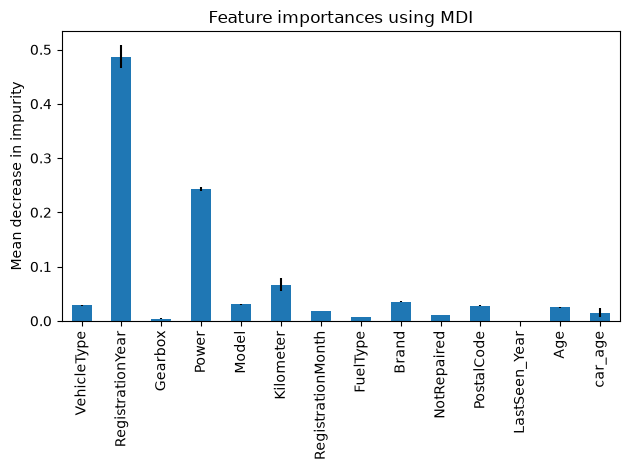

In [46]:
forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

## Градиентный бустинг с LGBM без категоризации и чистки:

In [47]:
%%time
df_raw = load_dataset('autos.csv').rename(columns={'Repaired': 'NotRepaired'})
cat_features = ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'NotRepaired', 'Brand']
X_raw = df_raw.drop(['DateCrawled', 'DateCreated', 'LastSeen', 'NumberOfPictures', 'Price'], axis=1)
for col in cat_features:
    X_raw[col] = X_raw[col].astype('category')
y_raw = df_raw['Price']
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.25, random_state=12345)

model_LGBMR = LGBMRegressor(max_depth=14, n_estimators=120, random_state=12345,
                            objective='regression', num_leaves=1400, n_jobs=4, verbose=-1)
model_LGBMR.fit(X_train_raw, y_train_raw, categorical_feature=cat_features)
predictions = model_LGBMR.predict(X_test_raw)
print('RMSE:', mean_squared_error(y_test_raw, predictions) ** 0.5)

RMSE: 1657.2185597330626
CPU times: user 12.3 s, sys: 224 ms, total: 12.5 s
Wall time: 3.69 s


## Анализ моделей

#### Вывод:
Простые модели (линейная регрессия — RMSE ≈ 2141–2657, дерево решений — ≈ 1904–1982) заметно уступают ансамблям. Случайный лес даёт хорошее качество (RMSE ≈ 1430 при 100 деревьях), но обучается заметно дольше бустингов. XGBoost и LightGBM дают сопоставимое качество (≈ 1473–1483 без тюнинга), при этом LightGBM обучается быстрее.

Лучший результат после подбора гиперпараметров — **LightGBM: RMSE ≈ 1405** на тестовой выборке (OHE-датасет; на датасете с Ordinal Encoding — ≈ 1427). LightGBM на «сырых» категориальных признаках без чистки данных даёт RMSE ≈ 1657 — предобработка данных даёт ощутимый выигрыш.

Итоговая рекомендация заказчику — LightGBM: лучшее сочетание качества, скорости предсказания и времени обучения.